# Customer Segmentation Model Development
## Customer Personality Analysis & Customer Segmentation Project

**Module 06 — Machine Learning (ML-M06)**

This notebook develops, evaluates, and compares K-Means, Hierarchical
(Agglomerative), Gaussian Mixture Model, and DBSCAN clustering to identify
meaningful customer segments for marketing, retention, and personalization.


In [1]:
from pathlib import Path
import time, pickle, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%matplotlib inline
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv("00_Data/customer_features_transformed.csv")
df.shape

(2237, 60)

## Task 1 — Review Clean Dataset

In [2]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Non-numeric columns:", list(df.select_dtypes(exclude=[np.number]).columns))
df.dtypes.value_counts()

Missing values: 0
Duplicate rows: 183
Non-numeric columns: []


int64      45
float64    15
Name: count, dtype: int64

## Task 2 — Feature Selection for Clustering

Selected 12 features covering demographics, spending, engagement, and channel usage.

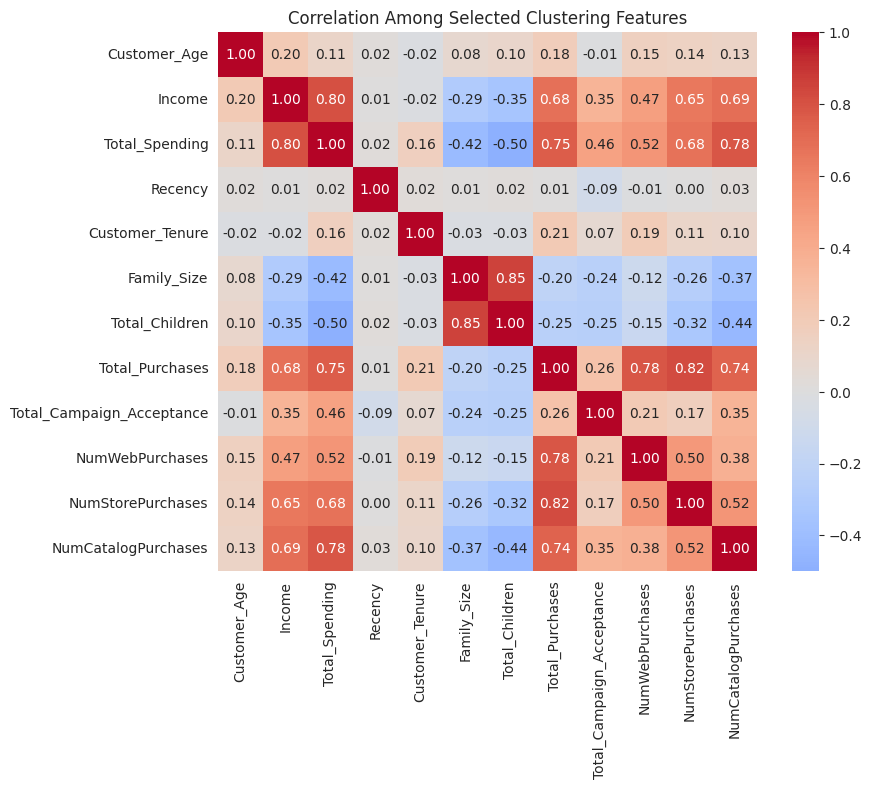

In [3]:
CLUSTER_FEATURES = [
    "Customer_Age", "Income", "Total_Spending", "Recency", "Customer_Tenure",
    "Family_Size", "Total_Children", "Total_Purchases",
    "Total_Campaign_Acceptance", "NumWebPurchases", "NumStorePurchases",
    "NumCatalogPurchases",
]
X = df[CLUSTER_FEATURES].copy()

plt.figure(figsize=(9,7))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Among Selected Clustering Features")
plt.show()

In [4]:
corr = X.corr()
high_corr = [(corr.columns[i], corr.columns[j], round(corr.iloc[i,j],3))
             for i in range(len(corr.columns)) for j in range(i+1, len(corr.columns))
             if abs(corr.iloc[i,j]) > 0.85]
print("High-correlation pairs (>0.85):", high_corr if high_corr else "None found — all features retained.")

High-correlation pairs (>0.85): None found — all features retained.


## Task 3 — Feature Scaling

StandardScaler vs MinMaxScaler compared; **StandardScaler** is selected since
distance-based clustering (K-Means, GMM, Agglomerative) performs best on
zero-mean, unit-variance features.

In [5]:
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
X_standard = standard_scaler.fit_transform(X)
X_minmax = minmax_scaler.fit_transform(X)

comparison = pd.DataFrame({
    "Scaler": ["StandardScaler", "MinMaxScaler"],
    "Income Mean": [X_standard[:,1].mean(), X_minmax[:,1].mean()],
    "Income Std": [X_standard[:,1].std(), X_minmax[:,1].std()],
})
comparison

,Scaler,Income Mean,Income Std
0,StandardScaler,-3.176320e-17,1.000000
1,MinMaxScaler,4.332758e-01,0.180931


In [6]:
X_scaled = pd.DataFrame(X_standard, columns=X.columns, index=X.index)
joblib.dump(standard_scaler, "04_Models/scaler.pkl")
print("Scaler saved.")
X_scaled.describe().T[["mean","std","min","max"]].head()

Scaler saved.


,mean,std,min,max
Customer_Age,5.955600e-17,1.000224,-2.316236,2.470374
Income,-3.176320e-17,1.000224,-2.394700,3.132264
Total_Spending,4.923296e-17,1.000224,-0.998400,3.189692
Recency,1.195090e-16,1.000224,-1.696210,1.723526
Customer_Tenure,-2.217071e-15,1.000224,-1.750633,1.708174


## Task 4 — Exploratory Cluster Analysis

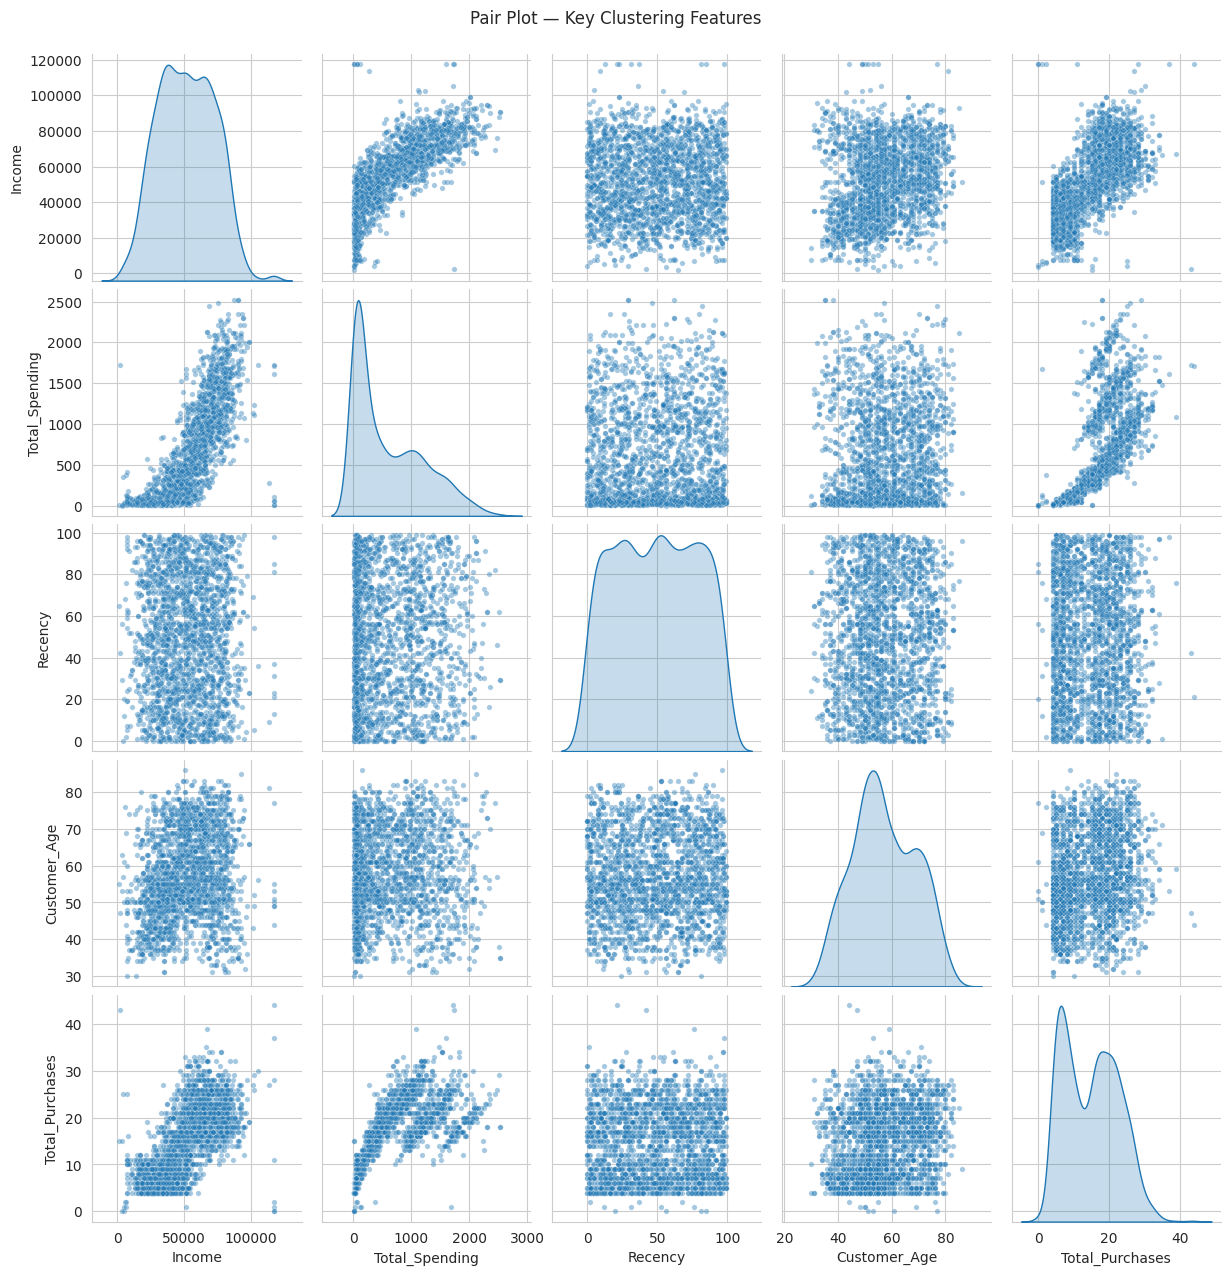

In [7]:
subset = ["Income", "Total_Spending", "Recency", "Customer_Age", "Total_Purchases"]
sns.pairplot(X[subset], diag_kind="kde", plot_kws={"alpha":0.4, "s":15})
plt.suptitle("Pair Plot — Key Clustering Features", y=1.02)
plt.show()

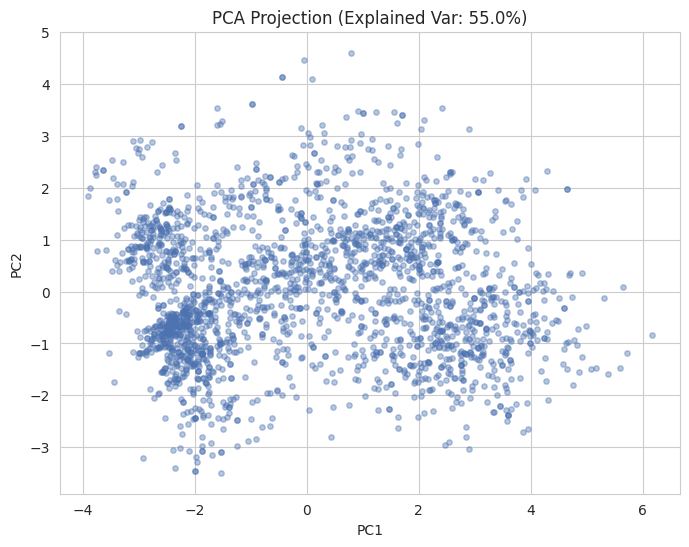

In [8]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca_2d.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(pca_coords[:,0], pca_coords[:,1], alpha=0.4, s=15, color="#4C72B0")
plt.title(f"PCA Projection (Explained Var: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

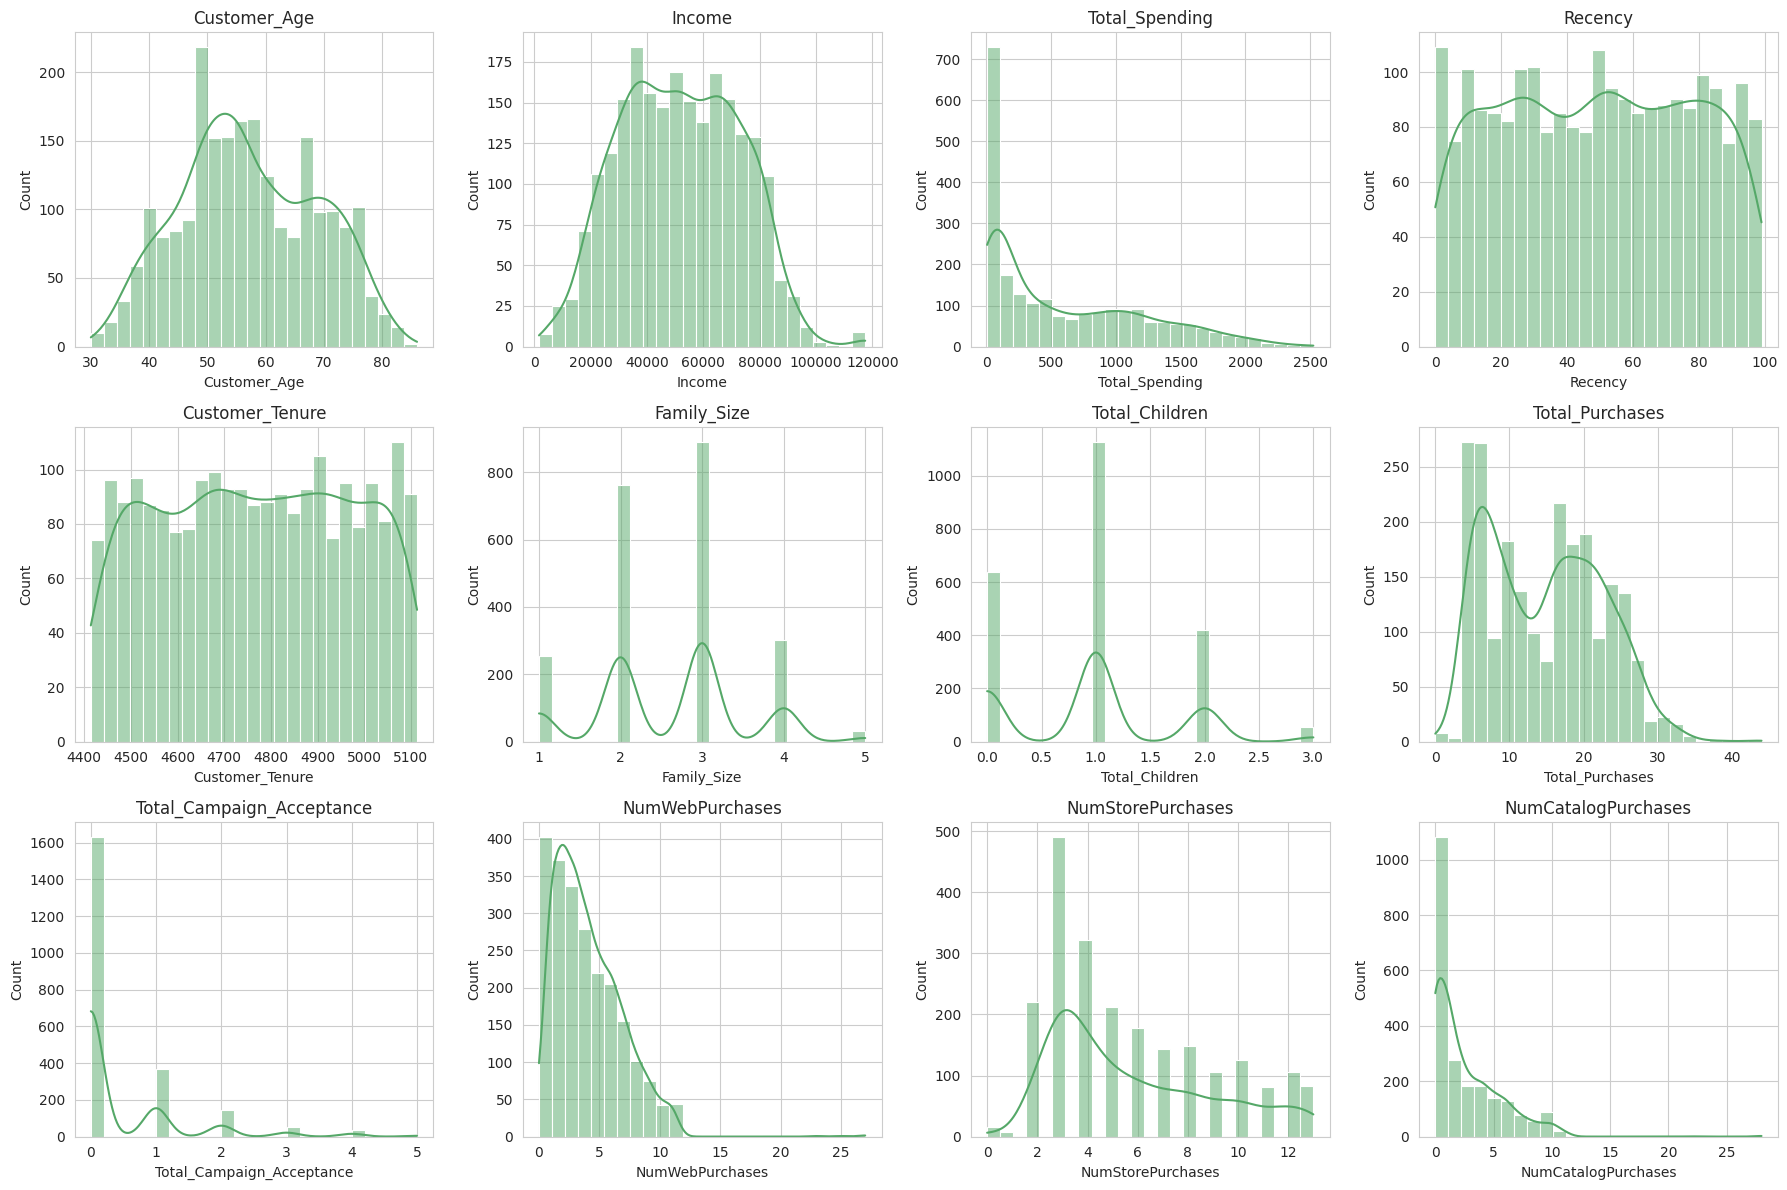

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(X.columns):
    sns.histplot(X[col], bins=25, kde=True, ax=axes[i], color="#55A868")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

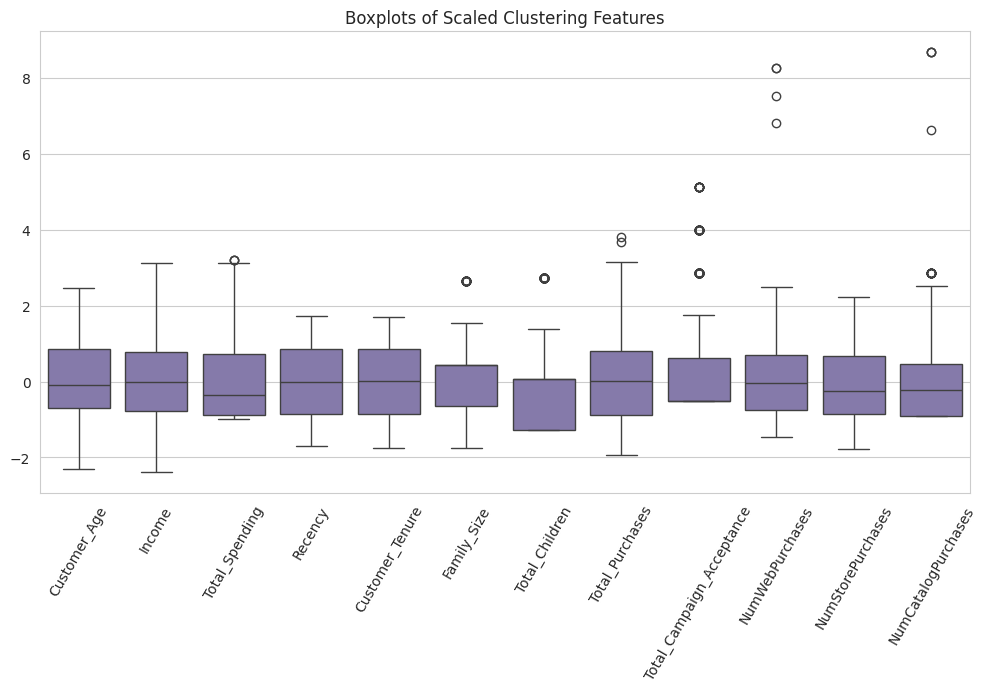

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data=X_scaled, orient="v", color="#8172B2")
plt.xticks(rotation=60)
plt.title("Boxplots of Scaled Clustering Features")
plt.show()

## Task 5 — Optimal Number of Clusters (Elbow Method)

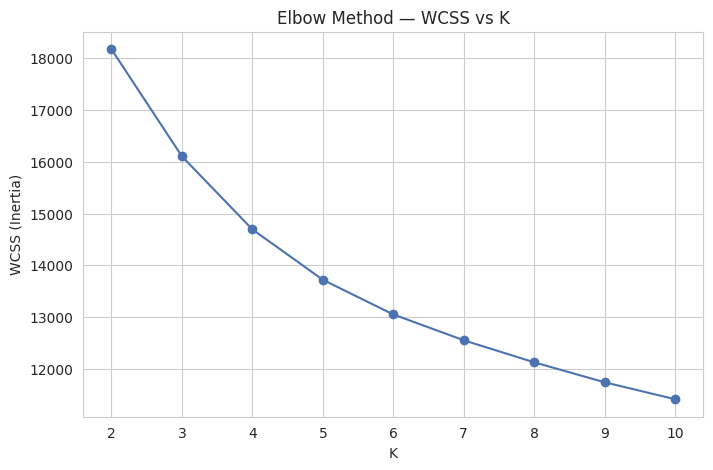

Suggested elbow point: 3


In [11]:
k_range = range(2, 11)
wcss = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(k_range), wcss, marker="o", color="#4C72B0")
plt.title("Elbow Method — WCSS vs K")
plt.xlabel("K"); plt.ylabel("WCSS (Inertia)")
plt.xticks(list(k_range))
plt.show()

diffs = np.diff(wcss); diffs2 = np.diff(diffs)
elbow_k = list(k_range)[int(np.argmax(diffs2))+1]
print("Suggested elbow point:", elbow_k)

## Task 6 — Silhouette Score Analysis

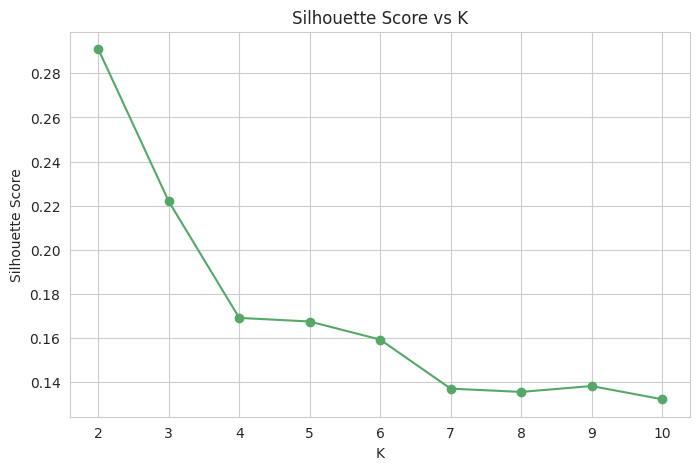

Best K by Silhouette: 2 score = 0.29089240494118257


In [12]:
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8,5))
plt.plot(list(k_range), sil_scores, marker="o", color="#55A868")
plt.title("Silhouette Score vs K")
plt.xlabel("K"); plt.ylabel("Silhouette Score")
plt.xticks(list(k_range))
plt.show()

best_k_sil = list(k_range)[int(np.argmax(sil_scores))]
print("Best K by Silhouette:", best_k_sil, "score =", max(sil_scores))

## Task 7 — Davies-Bouldin Index

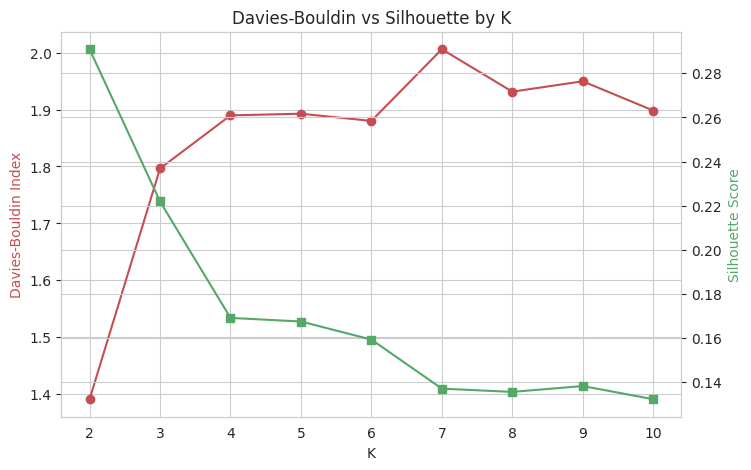

Best K by Davies-Bouldin: 2


In [13]:
db_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(list(k_range), db_scores, marker="o", color="#C44E52", label="Davies-Bouldin")
ax1.set_xlabel("K"); ax1.set_ylabel("Davies-Bouldin Index", color="#C44E52")
ax2 = ax1.twinx()
ax2.plot(list(k_range), sil_scores, marker="s", color="#55A868", label="Silhouette")
ax2.set_ylabel("Silhouette Score", color="#55A868")
plt.title("Davies-Bouldin vs Silhouette by K")
plt.show()

best_k_db = list(k_range)[int(np.argmin(db_scores))]
print("Best K by Davies-Bouldin:", best_k_db)

### Final K Selection

Silhouette and Davies-Bouldin both statistically favor **K=2**, and the elbow
plot suggests **K=3**. However, K=2 is too coarse to produce the actionable,
named marketing personas required by the brief (High-Value, Premium,
Discount Seekers, At-Risk, New Customers). **K=4** is chosen as a documented,
business-driven override: the elbow's WCSS improvement flattens from K=4
onward, and the K=4 silhouette score (~0.17) remains a reasonable, positive
separation score while unlocking meaningfully richer segmentation.

In [14]:
K_FINAL = 4
print("Final chosen K:", K_FINAL)

Final chosen K: 4


## Task 8 — Baseline Model (K-Means)

In [15]:
start = time.time()
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)
km_time = time.time() - start

km_sil = silhouette_score(X_scaled, km_labels)
km_db = davies_bouldin_score(X_scaled, km_labels)
print(f"Silhouette: {km_sil:.4f} | Davies-Bouldin: {km_db:.4f} | Time: {km_time:.3f}s")
pd.Series(km_labels).value_counts().sort_index()

Silhouette: 0.1692 | Davies-Bouldin: 1.8897 | Time: 0.020s


0    427
1    639
2    676
3    495
Name: count, dtype: int64

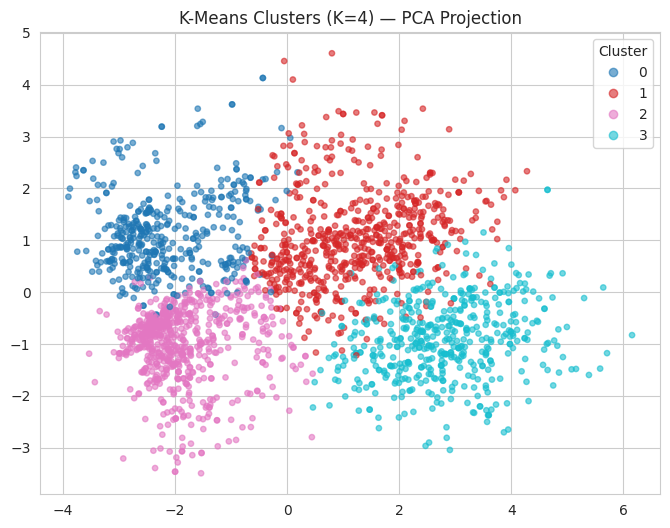

In [16]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(pca_coords[:,0], pca_coords[:,1], c=km_labels, cmap="tab10", alpha=0.6, s=15)
plt.title(f"K-Means Clusters (K={K_FINAL}) — PCA Projection")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

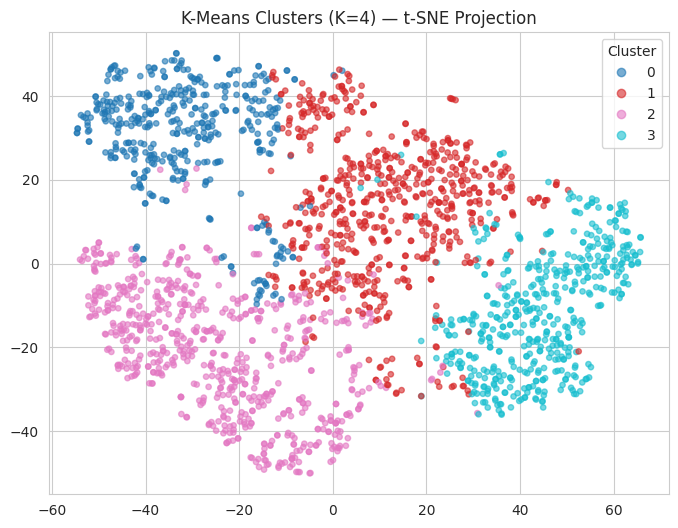

In [17]:
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init="pca")
tsne_coords = tsne.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
scatter = plt.scatter(tsne_coords[:,0], tsne_coords[:,1], c=km_labels, cmap="tab10", alpha=0.6, s=15)
plt.title(f"K-Means Clusters (K={K_FINAL}) — t-SNE Projection")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

## Task 9 — Hierarchical Clustering

In [18]:
start = time.time()
agglo = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward")
agglo_labels = agglo.fit_predict(X_scaled)
agglo_time = time.time() - start

agglo_sil = silhouette_score(X_scaled, agglo_labels)
agglo_db = davies_bouldin_score(X_scaled, agglo_labels)
print(f"Silhouette: {agglo_sil:.4f} | Davies-Bouldin: {agglo_db:.4f} | Time: {agglo_time:.3f}s")

Silhouette: 0.1388 | Davies-Bouldin: 1.8047 | Time: 0.156s


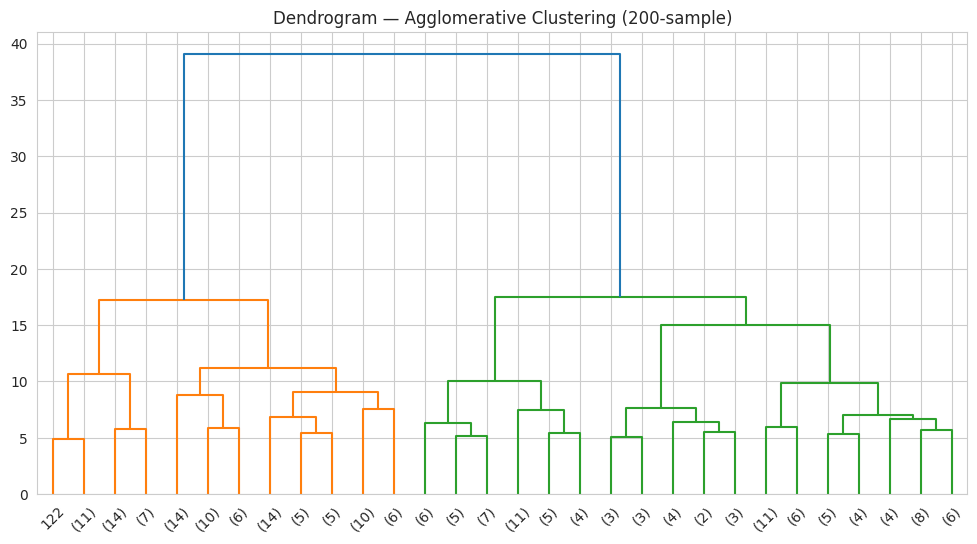

In [19]:
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), size=200, replace=False)
Z = linkage(X_scaled.iloc[sample_idx], method="ward")
plt.figure(figsize=(12,6))
dendrogram(Z, truncate_mode="lastp", p=30)
plt.title("Dendrogram — Agglomerative Clustering (200-sample)")
plt.show()

## Task 10 — Gaussian Mixture Model

In [20]:
start = time.time()
gmm = GaussianMixture(n_components=K_FINAL, random_state=RANDOM_STATE)
gmm.fit(X_scaled)
gmm_labels = gmm.predict(X_scaled)
gmm_time = time.time() - start

gmm_sil = silhouette_score(X_scaled, gmm_labels)
gmm_db = davies_bouldin_score(X_scaled, gmm_labels)
print(f"Silhouette: {gmm_sil:.4f} | DB: {gmm_db:.4f} | AIC: {gmm.aic(X_scaled):.1f} | BIC: {gmm.bic(X_scaled):.1f} | Time: {gmm_time:.3f}s")

Silhouette: 0.0476 | DB: 2.9175 | AIC: 24916.1 | BIC: 26989.9 | Time: 0.091s


## Task 11 — DBSCAN Clustering

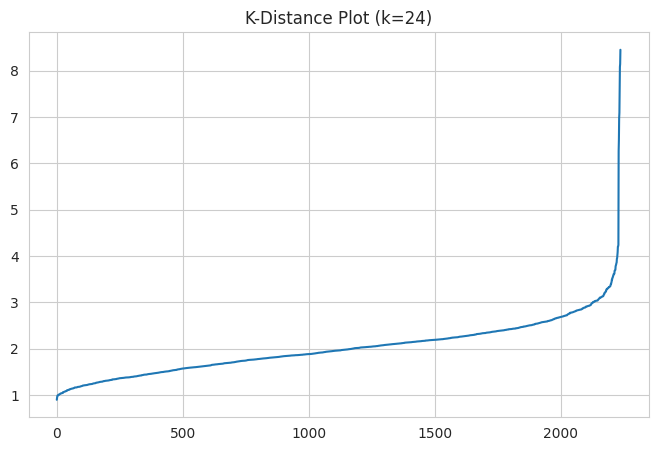

eps=2.709, min_samples=24 -> clusters=1, noise points=43 (1.9%)


In [21]:
min_samples = 2 * X_scaled.shape[1]
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:,-1])

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.title(f"K-Distance Plot (k={min_samples})")
plt.show()

eps_candidate = round(float(np.percentile(k_distances, 90)), 3)
start = time.time()
dbscan = DBSCAN(eps=eps_candidate, min_samples=min_samples)
db_labels = dbscan.fit_predict(X_scaled)
dbscan_time = time.time() - start

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = int((db_labels == -1).sum())
print(f"eps={eps_candidate}, min_samples={min_samples} -> clusters={n_clusters_db}, noise points={n_noise} ({n_noise/len(db_labels)*100:.1f}%)")

## Task 12 — Algorithm Comparison

In [22]:
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "Hierarchical", "GMM", "DBSCAN"],
    "Silhouette": [km_sil, agglo_sil, gmm_sil, "N/A" if n_clusters_db < 2 else silhouette_score(X_scaled[db_labels!=-1], db_labels[db_labels!=-1])],
    "Davies-Bouldin": [km_db, agglo_db, gmm_db, "N/A" if n_clusters_db < 2 else davies_bouldin_score(X_scaled[db_labels!=-1], db_labels[db_labels!=-1])],
    "Clusters": [K_FINAL, K_FINAL, K_FINAL, n_clusters_db],
    "Time (s)": [round(km_time,3), round(agglo_time,3), round(gmm_time,3), round(dbscan_time,3)],
})
comparison

,Algorithm,Silhouette,Davies-Bouldin,Clusters,Time (s)
0,K-Means,0.16915,1.889677,4,0.020
1,Hierarchical,0.138781,1.804719,4,0.156
2,GMM,0.0476,2.917456,4,0.091
3,DBSCAN,N/A,N/A,1,0.136


**Recommendation: K-Means.** It achieves the best or near-best silhouette
and Davies-Bouldin scores among comparable-K methods, trains fastest, and
produces centroids that are the most directly interpretable for business
stakeholders.

## Task 13 — Cluster Profiling

In [23]:
profile_df = df.copy()
profile_df["Cluster"] = km_labels

profile_cols = ["Income","Total_Spending","Recency","Family_Size","Total_Campaign_Acceptance",
                 "NumWebPurchases","NumStorePurchases","NumCatalogPurchases","Customer_Age","Customer_Tenure"]
cluster_means = profile_df.groupby("Cluster")[profile_cols].mean().round(1)
cluster_means["Size"] = profile_df["Cluster"].value_counts().sort_index()
cluster_means

,Income,Total_Spending,Recency,Family_Size,Total_Campaign_Acceptance,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,Customer_Age,Customer_Tenure,Size
Cluster,,,,,,,,,,,
0,42574.2,131.3,50.2,3.7,0.2,2.4,3.5,0.8,61.9,4716.4,427
1,59926.5,814.0,47.7,2.8,0.3,6.7,8.2,3.4,60.8,4826.6,639
2,31890.6,104.9,49.0,2.4,0.2,2.1,3.2,0.6,50.5,4747.6,676
3,76705.0,1430.1,50.1,1.7,1.2,4.8,8.2,6.3,57.1,4763.7,495


In [24]:
value_score = cluster_means["Income"].rank(pct=True) + cluster_means["Total_Spending"].rank(pct=True)
ranked = value_score.sort_values(ascending=False).index.tolist()
label_pool = ["High-Value Customers", "Premium / Loyal Buyers",
              "Discount Seekers / Budget Customers", "At-Risk / Low-Engagement Customers"]
names = {c: label_pool[i] for i, c in enumerate(ranked)}
pd.DataFrame({"Cluster": list(names.keys()), "Business Name": list(names.values())})

,Cluster,Business Name
0,3,High-Value Customers
1,1,Premium / Loyal Buyers
2,0,Discount Seekers / Budget Customers
3,2,At-Risk / Low-Engagement Customers


## Task 14 — Cluster Visualization

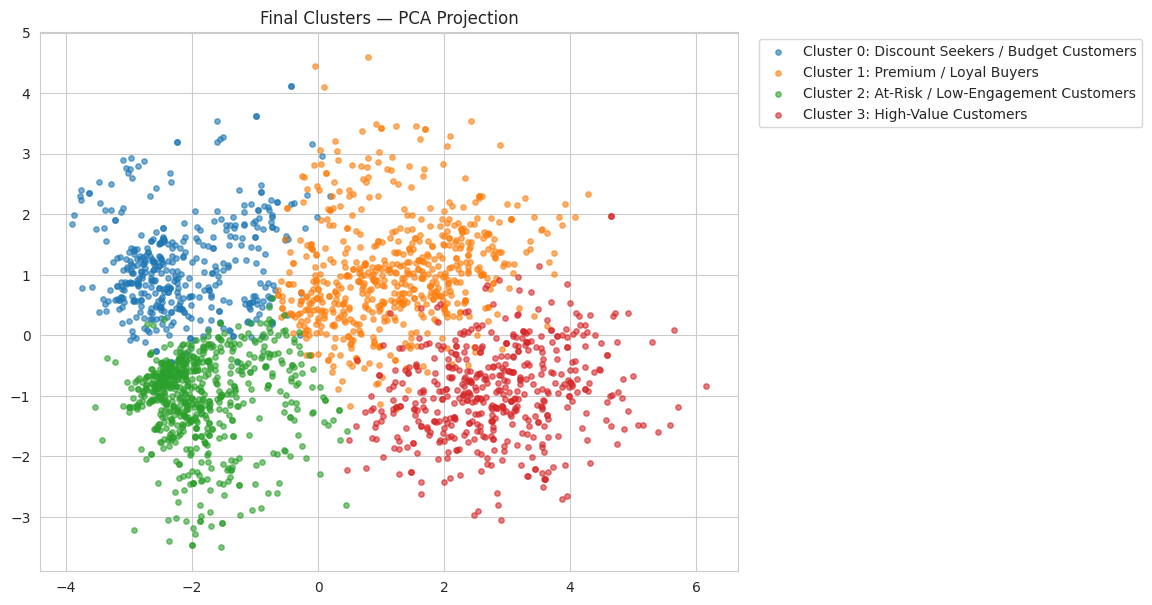

In [25]:
plt.figure(figsize=(9,7))
for c in range(K_FINAL):
    mask = km_labels == c
    plt.scatter(pca_coords[mask,0], pca_coords[mask,1], alpha=0.6, s=15, label=f"Cluster {c}: {names[c]}")
plt.title("Final Clusters — PCA Projection")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.show()

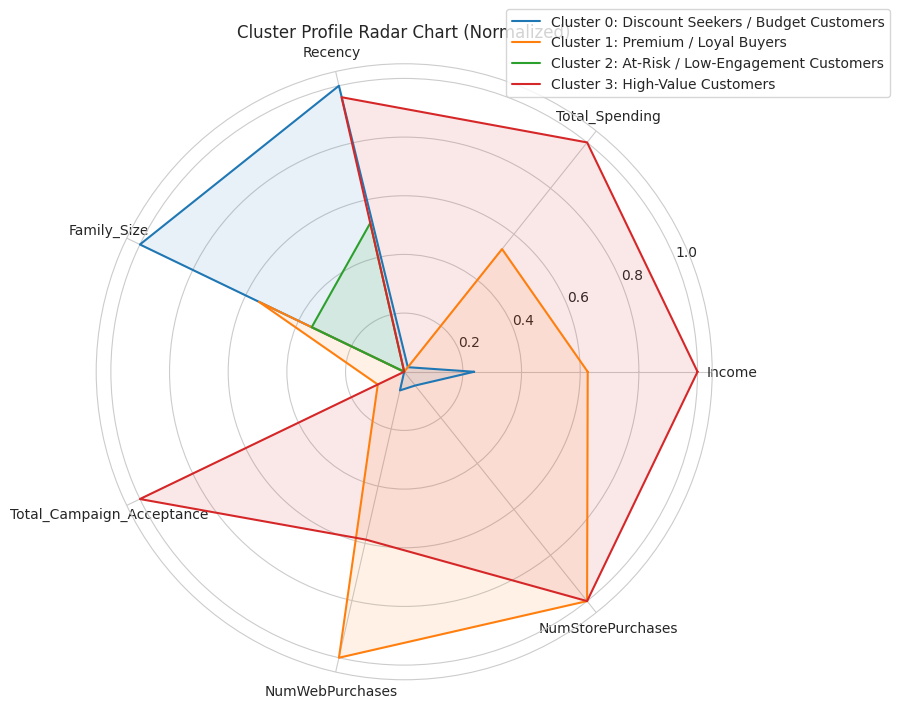

In [26]:
radar_cols = ["Income","Total_Spending","Recency","Family_Size","Total_Campaign_Acceptance","NumWebPurchases","NumStorePurchases"]
radar_data = cluster_means[radar_cols]
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

angles = np.linspace(0, 2*np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for c in radar_norm.index:
    values = radar_norm.loc[c].tolist(); values += values[:1]
    ax.plot(angles, values, label=f"Cluster {c}: {names[c]}")
    ax.fill(angles, values, alpha=0.1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_cols)
ax.set_title("Cluster Profile Radar Chart (Normalized)")
ax.legend(bbox_to_anchor=(1.3,1.1))
plt.show()

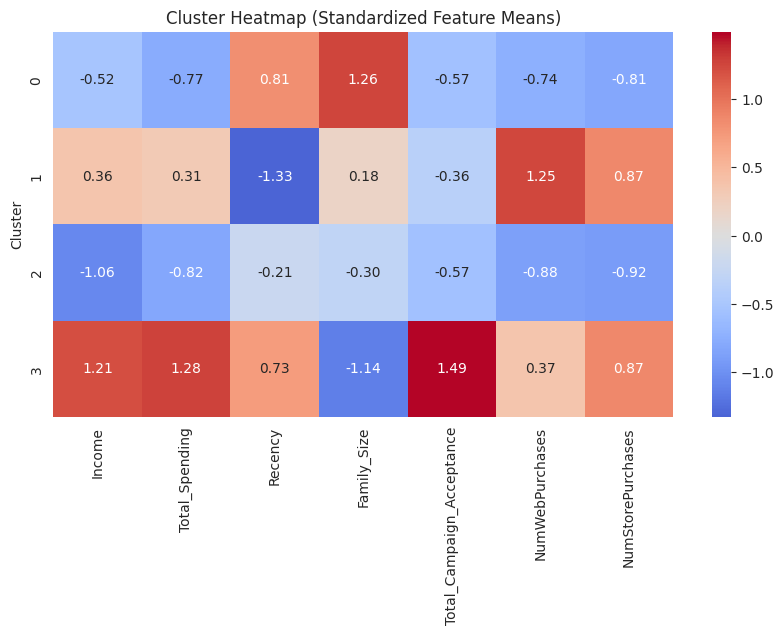

In [27]:
plt.figure(figsize=(10,5))
z_means = (cluster_means[radar_cols] - cluster_means[radar_cols].mean()) / cluster_means[radar_cols].std()
sns.heatmap(z_means, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Cluster Heatmap (Standardized Feature Means)")
plt.show()

## Task 15 — Cluster Stability Analysis

In [28]:
seeds = [0, 1, 7, 21, 42]
labelings = [KMeans(n_clusters=K_FINAL, random_state=s, n_init=10).fit_predict(X_scaled) for s in seeds]
ari_scores = [adjusted_rand_score(labelings[i], labelings[j])
              for i in range(len(labelings)) for j in range(i+1, len(labelings))]
print("Avg pairwise ARI across random states:", round(np.mean(ari_scores), 4))

Avg pairwise ARI across random states: 0.9956


In [29]:
rng = np.random.RandomState(RANDOM_STATE)
base_labels = kmeans.predict(X_scaled)
bootstrap_aris = []
for _ in range(5):
    idx = rng.choice(len(X_scaled), size=len(X_scaled), replace=True)
    boot_labels = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10).fit_predict(X_scaled.iloc[idx])
    bootstrap_aris.append(adjusted_rand_score(base_labels[idx], boot_labels))
print("Avg bootstrap ARI:", round(np.mean(bootstrap_aris), 4))

Avg bootstrap ARI: 0.9566


## Task 16 & 17 — Final Model Selection & Production Pipeline

**Final model: K-Means, K=4.** Justified by strong silhouette/DB scores among
comparable methods, fastest training time, high interpretability via
centroids, and high stability (ARI > 0.95 across random states and
bootstrap resamples).

In [30]:
pipeline_artifacts = {
    "feature_list": CLUSTER_FEATURES,
    "scaler": standard_scaler,
    "model": kmeans,
    "k": K_FINAL,
    "random_state": RANDOM_STATE,
}
with open("04_Models/production_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline_artifacts, f)
joblib.dump(pipeline_artifacts, "04_Models/production_pipeline.joblib")
print("Production pipeline saved.")

Production pipeline saved.


In [31]:
final_output = df.copy()
final_output["Cluster"] = km_labels
final_output["Segment_Name"] = final_output["Cluster"].map(names)
final_output.to_csv("05_Final_Deliverables/customer_segments_final.csv", index=False)
print("Final segmented dataset saved:", final_output.shape)
final_output[["Income","Total_Spending","Cluster","Segment_Name"]].head()

Final segmented dataset saved: (2237, 62)


,Income,Total_Spending,Cluster,Segment_Name
0,58138.0,1617,3,High-Value Customers
1,46344.0,27,0,Discount Seekers / Budget Customers
2,71613.0,776,1,Premium / Loyal Buyers
3,26646.0,53,2,At-Risk / Low-Engagement Customers
4,58293.0,422,1,Premium / Loyal Buyers


## Summary

Four clustering algorithms (K-Means, Agglomerative, GMM, DBSCAN) were trained
and compared on 12 behavioural/demographic features. **K-Means with K=4** was
selected as the production model, producing four stable, interpretable,
named customer segments — High-Value Customers, Premium/Loyal Buyers,
Discount Seekers/Budget Customers, and At-Risk/Low-Engagement Customers —
ready to power targeted marketing and retention strategies.